## gaussian splatting

In [1]:
import torch
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter, FuncAnimation
from matplotlib.patches import Ellipse, Rectangle

### 가우시안 렌더링과 관련 함수 정의

In [2]:
class shape:
    def __init__(self):
        pass

    def get_ndc_points(self, H, W, device):
        x = torch.arange(W, device=device)
        y = torch.arange(H, device=device)

        Y,X = torch.meshgrid([y,x], indexing="ij")
        Y = torch.flip(Y, dims=[0])
        NDCX = 2.0*(X+0.5) / W - 1.0
        NDCY = 2.0*(Y+0.5) / H - 1.0

        return torch.stack([NDCX,NDCY], dim=-1)
    
class gaussians(shape):
    def __init__(self, random, count = 0, device = None, dtype = None, n_sigma = 3.0):
        self.c = count
        self.device = device
        self.dtype = dtype
        self.n_sigma = n_sigma

        if random:
            self.mus = (torch.randn((count,2), device=device, dtype=dtype)*0.5).requires_grad_(True)
            self.sigmas = (torch.rand((count,2), device=device, dtype=dtype)*0.2+0.1).requires_grad_(True)
            self.alphas = (torch.rand(count, device=device, dtype=dtype)*0.5+0.1).requires_grad_(True)
            self.thetas = (torch.rand(count, device=device, dtype=dtype)*2.0* torch.pi).requires_grad_(True)
            self.colors = (torch.rand((count,3), device=device, dtype=dtype)).requires_grad_(True)

        else:
            self.mus = None
            self.sigmas = None
            self.alphas = None
            self.thetas = None
            self.colors = None
        
        self.frames = []
        
    def initialize(self, mus, sigmas, alphas, thetas, colors):
        self.c = mus.shape[0]
      
        self.device = mus.device
        self.dtype = mus.dtype

        self.mus = mus
        self.sigmas = sigmas
        self.alphas = alphas
        self.thetas = thetas
        self.colors = colors

    def render(self, H, W):
        #print(f"self.device : {self.device} , mus device : {self.mus.device}")
        P = self.get_ndc_points(H,W, self.device)
        image = torch.zeros((H,W,3), device=self.device)
        #print(f"render {self.c} gaussians")
        for i in range(self.c):
            mu, sigma, alpha, theta, color = self.mus[i], self.sigmas[i], self.alphas[i], self.thetas[i].squeeze(-1), self.colors[i]
            cos_t = torch.cos(theta)
            sin_t = torch.sin(theta)

            half_w = self.n_sigma * (torch.abs(cos_t) * sigma[0] + torch.abs(sin_t) * sigma[1]) 
            half_h = self.n_sigma * (torch.abs(sin_t) * sigma[0] + torch.abs(cos_t) * sigma[1])
            #print(f"P device : {P.device} , mus device : {self.mus.device}")

            #half_w = self.n_sigma * torch.sqrt((sigma[0] * cos_t)**2 + (sigma[1] * sin_t)**2)
            #half_h = self.n_sigma * torch.sqrt((sigma[0] * sin_t)**2 + (sigma[1] * cos_t)**2)

            x0, x1, y0, y1 = mu[0] - half_w, mu[0] + half_w, mu[1] - half_h, mu[1] + half_h
            bbox_mask = (P[...,0] >= x0) & (P[...,0] <= x1) & (P[...,1] >= y0) & (P[...,1] <= y1)

            if not torch.any(bbox_mask):
                continue

            diff = P[bbox_mask] - mu
            R = torch.stack([
                torch.stack([cos_t, -sin_t]),
                torch.stack([sin_t, cos_t])
            ])
            S = torch.diag(1.0/(sigma**2))
            
            diff = P[bbox_mask] - mu
            sigma_inv = R @ S @ R.T
            f = diff * (diff @ sigma_inv)
            f = torch.sum(f, dim=-1)
            exp = torch.exp(-0.5* f)
            rgbs = exp[..., None] * alpha * color
            image[bbox_mask] += rgbs          
        
        image = torch.clamp(image, 0.0, 1.0)
        return image
    

class triangle(shape):
    def __init__(self, vertices, indices, colors):
        self.device = vertices.device
        self.detype = vertices.dtype
        self.c = int(len(indices) / 3)
        
        self.vertices = vertices
        self.colors = colors
        self.indices = indices
       
    def cross_product(self, v0,v1,P):
        return (P[...,0] - v0[...,0]) *  (v1[...,1] - v0[...,1]) - (P[...,1] - v0[...,1]) *  (v1[...,0] - v0[...,0])
    
    def render(self, H, W):
        P = self.get_ndc_points(H, W, self.device)
        image = torch.zeros((H,W,3), device=self.device)
        
        for i in range(self.c):
            base_idx = i*3
            i0, i1, i2 = self.indices[base_idx], self.indices[base_idx+1], self.indices[base_idx+2]
            v0,v1,v2 = self.vertices[i0], self.vertices[i1], self.vertices[i2]
            c0,c1,c2 = self.colors[i0], self.colors[i1], self.colors[i2]

            area_2 = self.cross_product(v0,v1,v2)
            s = 1.0 if area_2 >=0.0 else -1.0
            area_2 = torch.where(torch.abs(area_2) < 1e-12, s * torch.tensor(1e-12, device=self.device), area_2)

            w0 = self.cross_product(v1,v2,P) / area_2
            w1 = self.cross_product(v2,v0,P) / area_2
            w2 = self.cross_product(v0,v1,P) / area_2

            mask = (w0 >= 0.0) & (w1 >= 0.0) & (w2 >= 0.0)
            rgbs = (c0 * w0[..., None] + c1 * w1[..., None] + c2 * w2[..., None])
            #print(f"mask shape : {mask.shape}, rgbs shape : {rgbs.shape}, image[mask] : {image[mask].shape}") # (x,y,2)
            image[mask] += rgbs[mask]

        image = torch.clamp(image, 0.0, 1.0)
        return image

In [3]:
def get_ndc_points(H, W, device):
        x = torch.arange(W, device=device)
        y = torch.arange(H, device=device)

        Y,X = torch.meshgrid([y,x], indexing="ij")
        Y = torch.flip(Y, dims=[0])
        NDCX = 2.0*(X+0.5) / W - 1.0
        NDCY = 2.0*(Y+0.5) / H - 1.0

        return torch.stack([NDCX,NDCY], dim=-1)

In [4]:
def render_gaussians( mus, sigmas, alphas, thetas, colors, H, W, n_sigma = 3.0):
        device = mus.device
        P = get_ndc_points(H,W,device)
        image = torch.zeros((H,W,3), device=device)
        c = mus.shape[0]
        for i in range(c):
            mu, sigma, alpha, theta, color = mus[i], sigmas[i], alphas[i], thetas[i].squeeze(-1), colors[i]
            cos_t = torch.cos(theta)
            sin_t = torch.sin(theta)

            #half_w = n_sigma * (torch.abs(cos_t) * sigma[0] + torch.abs(sin_t) * sigma[1]) 
            #half_h = n_sigma * (torch.abs(sin_t) * sigma[0] + torch.abs(cos_t) * sigma[1])
           
            half_w = n_sigma * torch.sqrt((sigma[0] * cos_t)**2 + (sigma[1] * sin_t)**2)
            half_h = n_sigma * torch.sqrt((sigma[0] * sin_t)**2 + (sigma[1] * cos_t)**2)

            x0, x1, y0, y1 = mu[0] - half_w, mu[0] + half_w, mu[1] - half_h, mu[1] + half_h
            bbox_mask = (P[...,0] >= x0) & (P[...,0] <= x1) & (P[...,1] >= y0) & (P[...,1] <= y1)

            if not torch.any(bbox_mask):
                continue

            diff = P[bbox_mask] - mu
            R = torch.stack([
                torch.stack([cos_t, -sin_t]),
                torch.stack([sin_t, cos_t])
            ])
            S = torch.diag(1.0/(sigma**2))
            
            diff = P[bbox_mask] - mu
            sigma_inv = R @ S @ R.T
            f = diff * (diff @ sigma_inv)
            f = torch.sum(f, dim=-1)
            exp = torch.exp(-0.5* f)
            rgbs = exp[..., None] * alpha * color
            image[bbox_mask] += rgbs          
        
        image = torch.clamp(image, 0.0, 1.0)
        return image

In [5]:
def save_results(filename, frames, fps):
    fig, ax = plt.subplots(1,1,figsize=(8,8))
    ax.axis('off')
    ax.set_title('gaussian training')
    image = ax.imshow(frames[0].cpu().detach().numpy(), extent=[-1, 1, -1, 1], vmin=0.0, vmax=1.0, interpolation="nearest", origin="upper")
    txt = ax.text(0.5,-0.05,"iteration : 0", fontsize=12, transform=ax.transAxes, ha='center')

    def update(idx):
        image.set_array(frames[idx].cpu().detach().numpy())
        txt.set_text(f"iteration : {idx}")
        return [image, txt]
    
    writer = FFMpegWriter(fps=fps, bitrate=1800)
    animation = FuncAnimation(fig, update, frames=len(frames), interval=1000/fps, blit=True)
    animation.save(filename=filename, writer=writer)
    print(f"Video saved to {filename}")
    plt.close(fig)

### 가우시안에 대한 patch 렌더링 함수 준비

In [6]:
def render_rectangle_patch(ax, g : gaussians):
    for i in range(g.c):
        mu, sigma, theta,  = g.mus[i].detach().numpy(), g.sigmas[i].detach().numpy(), g.thetas[i]
        cos_t = torch.cos(theta)
        sin_t = torch.sin(theta)
        half_w = g.n_sigma * torch.sqrt((sigma[0] * cos_t)**2 + (sigma[1] * sin_t)**2).item()
        
        
        patch = Rectangle((mu[0].item() - half_w, mu[1].item() - half_w), width=half_w*2.0, height=half_w*2.0, angle=0,
                          edgecolor='cyan', facecolor='none', linewidth=2.0, alpha=0.9)
        ax.add_patch(patch)

def render_ellipse_patch(ax, g : gaussians):
    for i in range(g.c):
        mu, sigma, theta,  = g.mus[i].cpu().detach().numpy(), g.sigmas[i].cpu().detach().numpy(), g.thetas[i]
        degrees = torch.rad2deg(theta)
        patch = Ellipse((mu[0].item(), mu[1].item()), width=g.n_sigma*sigma[0].item()*2.0, height=g.n_sigma*sigma[1].item()*2.0, angle=degrees,
                          edgecolor='cyan', facecolor='none', linewidth=2.0, alpha=0.9)
        ax.add_patch(patch)
        ax.scatter(mu[0], mu[1], c='cyan', s=100, marker="x", linewidths=2, alpha=0.9)

def render_patches(ax, g : gaussians, render_rectangle, render_ellipse, render_scatter, color = 'cyan', n_sigma = 3.0):
     for i in range(g.c):
        mu, sigma, theta,  = g.mus[i].cpu().detach().numpy(), g.sigmas[i].cpu().detach().numpy(), g.thetas[i]
        degrees = torch.rad2deg(theta)
        cos_t = torch.cos(theta)
        sin_t = torch.sin(theta)
        half_w = n_sigma * torch.sqrt((sigma[0] * cos_t)**2 + (sigma[1] * sin_t)**2).item()
        half_h = n_sigma * torch.sqrt((sigma[0] * sin_t)**2 + (sigma[1] * cos_t)**2).item()
        if render_rectangle:
            r = Rectangle((mu[0].item() - half_w, mu[1].item() - half_h), width=half_w*2.0, height=half_h*2.0, angle=0,
                              edgecolor=color, facecolor='none', linewidth=2.0, alpha=0.9)
            ax.add_patch(r)
        if render_ellipse:
            e = Ellipse((mu[0].item(), mu[1].item()), width=n_sigma*sigma[0].item()*2.0, height=n_sigma*sigma[1].item()*2.0, angle=degrees,
                              edgecolor=color, facecolor='none', linewidth=2.0, alpha=0.9)
            ax.add_patch(e)

        if render_scatter:
            ax.scatter(mu[0], mu[1], c=color, s=30, marker="x", linewidths=2, alpha=0.9)

### 변수들 선언

In [7]:
device = 'cuda'
dtype = torch.float32

mus = torch.tensor([[0.0, 0.0]], device=device, dtype=dtype).detach().requires_grad_(True)
sigmas = torch.tensor([[0.7,0.4]], device=device, dtype=dtype).detach().requires_grad_(True)
alphas = torch.tensor([[1.0]], device=device, dtype=dtype).detach().requires_grad_(True)
thetas = torch.tensor([[torch.pi/5]], device=device, dtype=dtype).detach().requires_grad_(True)
colors = torch.tensor([[1.0, 1.0, 0.0]], device=device, dtype=dtype).detach().requires_grad_(True)

init_vertices = torch.tensor([[-0.6,-0.2],
                              [0.1,0.6],
                              [0.45, -0.4]],
                                      device=device, dtype=dtype)
init_colors = torch.diag(torch.tensor([1.0,1.0,1.0],device=device, dtype=dtype))
init_indices = [0,1,2]

### 함수 테스트

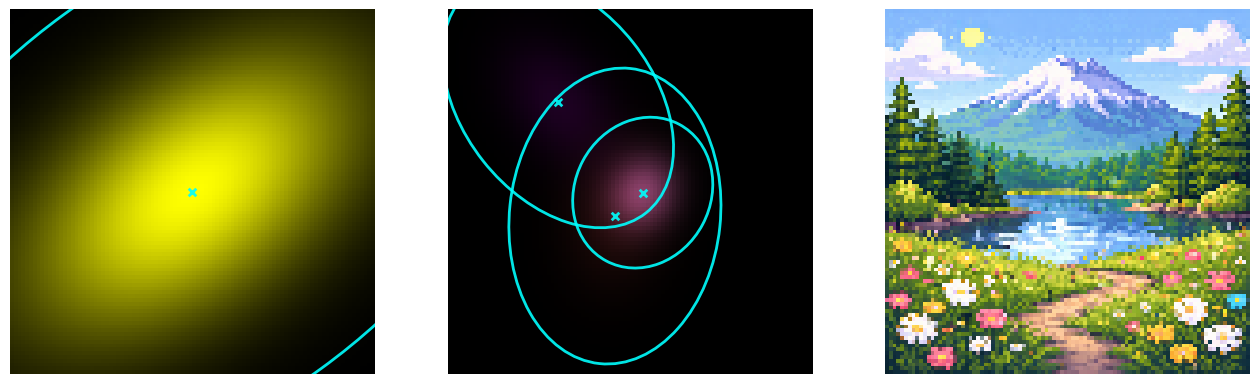

In [8]:
from PIL import Image
from torchvision.transforms.functional import pil_to_tensor

img = Image.open("target.png").convert("RGB")
target = pil_to_tensor(img).float() / 255.0
target_image = target.permute(1,2,0)
H = target_image.size(0)
W = target_image.size(1)


test_g  = gaussians(False, 1, device, dtype)
test_g.initialize(mus, sigmas, alphas, thetas, colors)
image = test_g.render(H,W)

test_g_r  = gaussians(True, 3, device, dtype, 3.0)
image_r = test_g_r.render(H,W)

target_image = target_image.type_as(image)
if image.is_cuda:
    target_image = target_image.cuda(target_image.get_device())

init_triangle = triangle(init_vertices, init_indices, init_colors)
#target_image = init_triangle.render(H,W)

temp_fig, temp_ax = plt.subplots(1,3, figsize=(16,5))
temp_ax[0].axis('off')
temp_ax[1].axis('off')
temp_ax[2].axis('off')

temp_ax[0].imshow(image.cpu().detach().numpy(), extent=[-1, 1, -1, 1], vmin=0.0, vmax=1.0, interpolation="nearest", origin="upper")
temp_ax[1].imshow(image_r.cpu().detach().numpy(), extent=[-1, 1, -1, 1], vmin=0.0, vmax=1.0, interpolation="nearest", origin="upper")
temp_ax[2].imshow(target_image.cpu().detach().numpy(), extent=[-1, 1, -1, 1], vmin=0.0, vmax=1.0, interpolation="nearest", origin="upper")

render_patches(temp_ax[0],test_g, True, True ,True)
render_patches(temp_ax[1],test_g_r, False, True ,True)

temp_ax[0].set_xlim(-1, 1)
temp_ax[0].set_ylim(-1, 1)
temp_ax[0].set_aspect('equal')

temp_ax[1].set_xlim(-1, 1)
temp_ax[1].set_ylim(-1, 1)
temp_ax[1].set_aspect('equal')
plt.show()

### 가우시안 분할 함수 준비

In [9]:
def split_gaussians(old, max_sigma = 0.3):
    old_mus, old_sigmas, old_alphas, old_thetas, old_colors = old

    new_mus = old_mus.detach().clone()
    new_sigmas = old_sigmas.detach().clone()
    new_alphas = old_alphas.detach().clone()
    new_thetas = old_thetas.detach().clone()
    new_colors = old_colors.detach().clone()

    added_mus, added_sigmas, added_thetas, added_alphas, added_colors = [], [], [], [], []

    max_value = new_sigmas.max(dim=-1).values
    mask = max_value >= max_sigma
    
    if not torch.any(mask):
        return (new_mus, 
            new_sigmas,
            new_alphas,
            new_thetas,
            new_colors)
    idx = torch.nonzero(mask).flatten()

    
    for i in idx:
        sigma = old_sigmas[i]
        alpha = old_alphas[i]
        mu = old_mus[i]
        color = old_colors[i]
        theta = old_thetas[i].squeeze(-1)

        cos_t = torch.cos(theta)
        sin_t = torch.sin(theta)
        
        if sigma[0] >= sigma[1]:
            dir0 = torch.stack([cos_t * sigma[0], sin_t * sigma[0]])
        else:
            dir0 = torch.stack([-sin_t * sigma[1], cos_t * sigma[1]])

        offset = dir0 * 0.35
        sigma = sigma * 0.7
        alpha = alpha * 0.5
  
        new_mus[i] = offset + mu
        new_sigmas[i] = sigma
        new_alphas[i] = alpha

        added_mus.append(mu - offset)
      
        added_sigmas.append(sigma)
        added_alphas.append(alpha) 
        added_thetas.append(old_thetas[i]) 
        added_colors.append(color)

    #print(new_sigmas.shape)
    #print(torch.stack(added_sigmas).shape)  
    return (torch.cat([new_mus, torch.stack(added_mus)], dim=0),
        torch.cat([new_sigmas, torch.stack(added_sigmas)], dim=0),
        torch.cat([new_alphas, torch.stack(added_alphas)], dim=0),
        torch.cat([new_thetas, torch.stack(added_thetas)], dim=0),
        torch.cat([new_colors, torch.stack(added_colors)], dim=0))

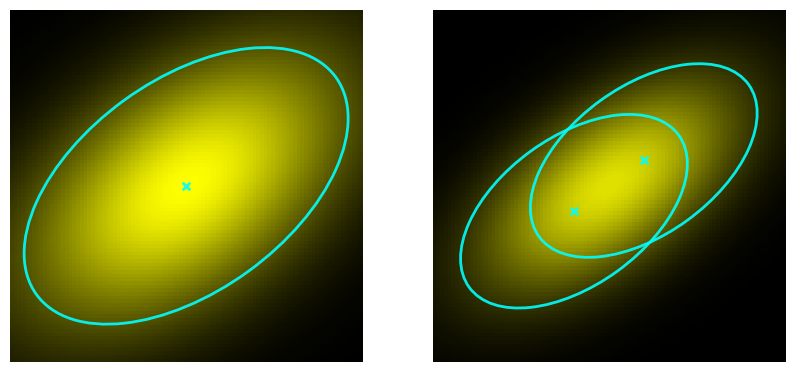

In [10]:
temp_fig0, temp_ax0 = plt.subplots(1,2, figsize=(10,5))
temp_ax0[0].axis('off')
temp_ax0[1].axis('off')

temp_ax0[0].imshow(image.detach().cpu().numpy(), extent=[-1, 1, -1, 1], vmin=0.0, vmax=1.0, interpolation="nearest", origin="upper")
render_patches(temp_ax0[0], test_g, False, True ,True, n_sigma=1.5)

m,s,a,t,c = split_gaussians((test_g.mus, test_g.sigmas,test_g.alphas,test_g.thetas,test_g.colors))
test_g.initialize(m,s,a,t,c)
split_test_image = test_g.render(H, W)
temp_ax0[1].imshow(split_test_image.detach().cpu().numpy(), extent=[-1, 1, -1, 1], vmin=0.0, vmax=1.0, interpolation="nearest", origin="upper")
render_patches(temp_ax0[1], test_g, False, True ,True, n_sigma=1.5)

temp_ax0[0].set_xlim(-1, 1)

temp_ax0[1].set_xlim(-1, 1)

plt.show()

### gaussian clone

In [11]:
def clone_gaussian(old, mus_grad, grad_threshold=0.1, max_sigma = 0.3):
    m, s, a, t, c = old
    

    if mus_grad is None:
        return m, s, t, a, c
    
    norm_grad = torch.norm(mus_grad, dim=-1)
    clone_mask = norm_grad >= grad_threshold
    
    if not torch.any(clone_mask):
        return m, s, a, t, c
    
    sigma_values = s.max(dim=-1).values
    split_mask = sigma_values >= max_sigma
    clone_mask = clone_mask & ~split_mask

    if not torch.any(clone_mask):
        return m, s, a, t, c    
    
    added_mus = m[clone_mask].clone()
    added_sigmas = s[clone_mask].clone()
    added_thetas = t[clone_mask].clone()
    added_alphas = a[clone_mask].clone()
    added_colors = c[clone_mask].clone()

    return (torch.cat([m, added_mus], dim=0),
        torch.cat([s, added_sigmas], dim=0),
        torch.cat([a, added_alphas], dim=0),
        torch.cat([t, added_thetas], dim=0),
        torch.cat([c, added_colors], dim=0))    

In [12]:
mus_demo_c = torch.tensor([[0.0, 0.0]], device=device, dtype=dtype)
sigmas_demo_c = torch.tensor([[0.2, 0.2]], device=device, dtype=dtype)
thetas_demo_c = torch.tensor([0.0], device=device, dtype=dtype)
opacities_demo_c = torch.tensor([0.5], device=device, dtype=dtype)
rgbs_demo_c = torch.tensor([[0.0, 1.0, 0.0]], device=device, dtype=dtype) # Green

mus_grad_demo = torch.tensor([[1.0, 1.0]], device=device, dtype=dtype)

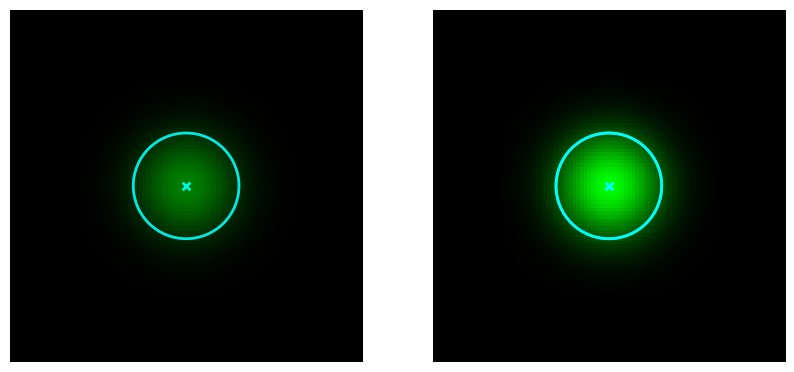

In [13]:
temp_fig_c, temp_ax_c = plt.subplots(1,2, figsize=(10,5))
temp_ax_c[0].axis('off')
temp_ax_c[1].axis('off')

clone_g = gaussians(False)
clone_g.initialize(mus_demo_c, sigmas_demo_c, opacities_demo_c, thetas_demo_c, rgbs_demo_c)
before_image_c = clone_g.render(H,W)

temp_ax_c[0].imshow(before_image_c.detach().cpu().numpy(), extent=[-1, 1, -1, 1], vmin=0.0, vmax=1.0, interpolation="nearest", origin="upper")
render_patches(temp_ax_c[0], clone_g, False, True ,True, n_sigma=1.5)

m,s,a,t,c = clone_gaussian((clone_g.mus, clone_g.sigmas,clone_g.alphas,clone_g.thetas,clone_g.colors), mus_grad_demo)
clone_g.initialize(m,s,a,t,c)
after_image_c = clone_g.render(H, W)
temp_ax_c[1].imshow(after_image_c.detach().cpu().numpy(), extent=[-1, 1, -1, 1], vmin=0.0, vmax=1.0, interpolation="nearest", origin="upper")
render_patches(temp_ax_c[1], clone_g, False, True ,True, n_sigma=1.5)

temp_ax_c[0].set_xlim(-1, 1)
temp_ax_c[1].set_xlim(-1, 1)

plt.show()

### gaussian split & clone 시에 state 유지

In [14]:
def cat_and_set_state(optim: torch.optim.Adam, old_param, new):
    group = optim.param_groups[0]
    idx = None
    for i, p in enumerate(group["params"]):
        if p is old_param:
            idx = i
            break
    
    device= old_param.device
    dtype = old_param.dtype

    with torch.no_grad():
        combined = torch.cat([old_param.detach(), new.to(device=device,dtype=dtype)], dim=0)

    new_param = torch.nn.Parameter(combined)
    group["params"][idx] = new_param
    
    state = optim.state.pop(old_param, {})
    step = state.get("step", torch.zeros_like(old_param))
    exp_avg = state.get("exp_avg", torch.zeros_like(old_param))
    exp_avg_sq = state.get("exp_avg_sq", torch.zeros_like(old_param))

    optim.state[new_param] = {
        "step": step,
        "exp_avg" : torch.cat([exp_avg, torch.zeros_like(new)], dim=0),
        "exp_avg_sq" : torch.cat([exp_avg_sq, torch.zeros_like(new)], dim=0)
    }

    return new_param

def add_optimizer(optim : torch.optim.Adam, old, full, prev_count):
    # 기존에 갖고 있던 state를 그대로 넘겨주면 된다
    
    old_m, old_s, old_a, old_t, old_c = old
    f_m, f_s, f_a, f_t, f_c = full

    old_m.data[:] = f_m[:prev_count]
    old_s.data[:] = f_s[:prev_count]
    old_a.data[:] = f_a[:prev_count]
    old_t.data[:] = f_t[:prev_count]
    old_c.data[:] = f_c[:prev_count]

    new_m = f_m[prev_count:]
    new_s = f_s[prev_count:]
    new_a = f_a[prev_count:]
    new_t = f_t[prev_count:]
    new_c = f_c[prev_count:]

    cat_m = cat_and_set_state(optim, old_m, new_m)
    cat_s = cat_and_set_state(optim, old_s, new_s)
    cat_a = cat_and_set_state(optim, old_a, new_a)
    cat_t = cat_and_set_state(optim, old_t, new_t)
    cat_c = cat_and_set_state(optim, old_c, new_c)

    return cat_m, cat_s, cat_a, cat_t, cat_c

### opacity 값이 작을 시에 prune

In [15]:
def purne_gaussian(old, min_opacity = 0.01):
    m, s, a, t, c = old
      
    mask = a >= min_opacity
    #print(f"a.shape : {a.shape}")
    return (m[mask],
        s[mask],
        a[mask],
        t[mask],
        c[mask],
        mask )   


In [16]:
def cat_and_remove_state(optim : torch.optim.Adam, old_param, keep_mask):
    group = optim.param_groups[0]
    idx= None
    for i,p in enumerate(group["params"]):
        if p is old_param:
            idx = i
            break

    if idx is None:
        raise ValueError("Parameter not found in optimizer")
    new = old_param.data[keep_mask]
    new_param = torch.nn.Parameter(new)
    group["params"][idx] = new_param

    state = optim.state.pop(old_param, {})
    if state:
        step = state.get("step", 0)
        exp_avg = state.get("exp_avg", torch.zeros_like(old_param))
        exp_avg_sq = state.get("exp_avg_sq", torch.zeros_like(old_param))
        
        
        optim.state[new_param] = {
            "step" : step,
            "exp_avg" : exp_avg[keep_mask],
            "exp_avg_sq" : exp_avg_sq[keep_mask]
        }

    return new_param

def remove_optimizer(optim : torch.optim.Adam, old, keep_mask):
    
    m, s, a, t, c = old
    #print(keep_mask.shape)
    new_mus = cat_and_remove_state(optim, m, keep_mask)
    new_sigmas = cat_and_remove_state(optim, s, keep_mask)
    new_thetas = cat_and_remove_state(optim, t, keep_mask)
    new_alphas = cat_and_remove_state(optim, a, keep_mask)
    new_colors = cat_and_remove_state(optim, c, keep_mask)

    return (new_mus, 
            new_sigmas,
            new_alphas,
            new_thetas,
            new_colors)

In [17]:
mus_demo_p = torch.tensor([[0.0, 0.0], [0.5, 0.5], [-0.3, 0.3]], dtype=torch.float32)
sigmas_demo_p = torch.tensor([[0.2, 0.2], [0.15, 0.15], [0.25, 0.2]], dtype=torch.float32)
thetas_demo_p = torch.tensor([0.0, 0.5, -0.3], dtype=torch.float32)
opacities_demo_p = torch.tensor([0.7, 0.005, 0.6], dtype=torch.float32)  # Middle one is nearly transparent
rgbs_demo_p = torch.tensor([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]], dtype=torch.float32)


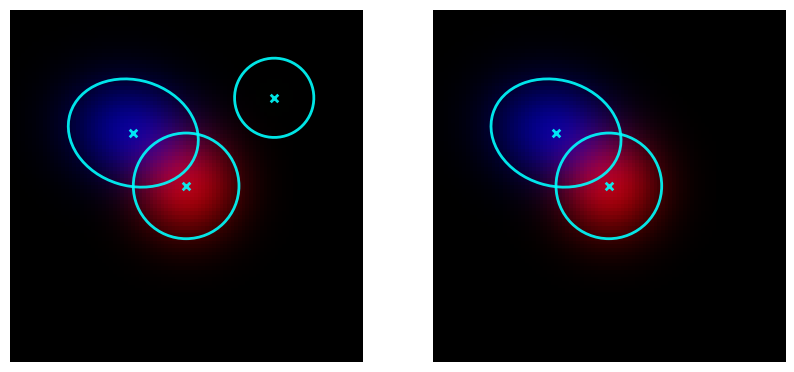

In [18]:
temp_fig_p, temp_ax_p = plt.subplots(1,2, figsize=(10,5))
temp_ax_p[0].axis('off')
temp_ax_p[1].axis('off')

purne_g = gaussians(False)
purne_g.initialize(mus_demo_p, sigmas_demo_p, opacities_demo_p, thetas_demo_p, rgbs_demo_p)
before_image_p = purne_g.render(H,W)

temp_ax_p[0].imshow(before_image_p.detach().cpu().numpy(), extent=[-1, 1, -1, 1], vmin=0.0, vmax=1.0, interpolation="nearest", origin="upper")
render_patches(temp_ax_p[0], purne_g, False, True ,True, n_sigma=1.5)

m_p, s_p, a_p, t_p, c_p, keep_mask = purne_gaussian((purne_g.mus, purne_g.sigmas, purne_g.alphas, purne_g.thetas, purne_g.colors ))
purne_g.initialize(m_p,s_p,a_p,t_p,c_p)
after_image_p = purne_g.render(H, W)
temp_ax_p[1].imshow(after_image_p.detach().cpu().numpy(), extent=[-1, 1, -1, 1], vmin=0.0, vmax=1.0, interpolation="nearest", origin="upper")
render_patches(temp_ax_p[1], purne_g, False, True ,True, n_sigma=1.5)

temp_ax_p[0].set_xlim(-1, 1)
temp_ax_p[1].set_xlim(-1, 1)

plt.show()

In [19]:
import torch.nn.functional as F


def gaussian(window_size, sigma):
        mu = window_size // 2
        gauss = torch.exp(torch.tensor([-0.5*(x - mu)**2 / (sigma**2) for x in range(window_size)]))
        return gauss / gauss.sum()

def create_window(window_size, channel):
    window_1D = gaussian(window_size, 1.5).unsqueeze(1)    
    window_2D = window_1D.mm(window_1D.t()).float().unsqueeze(0).unsqueeze(0)
    window = window_2D.expand(channel, 1, window_size, window_size).contiguous()
    return window

def ssim(img1, img2, window_size=11):
    if img1.ndim == 3:
        img1 = img1.permute(2,0,1).unsqueeze(0)
        img2 = img2.permute(2,0,1).unsqueeze(0)
    
    c = img1.size(1)
    window = create_window(window_size, c)
    if img1.is_cuda:
         window = window.cuda(img1.get_device())
         
    window= window.type_as(img1)
    mu1 = F.conv2d(img1, window, padding=window_size//2, groups=c)
    mu2 = F.conv2d(img2, window, padding=window_size//2, groups=c)
    mu1_sq = mu1.pow(2)
    mu2_sq = mu2.pow(2)
    mu1_mu2 = mu1* mu2
    sigma1_sq = F.conv2d(img1 * img1, window, padding=window_size//2, groups=c) - mu1_sq
    sigma2_sq = F.conv2d(img2 * img2, window, padding=window_size//2, groups=c) - mu2_sq
    sigma12 = F.conv2d(img1 * img2, window, padding=window_size//2, groups=c) - mu1_mu2

    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    ssim = ((2.0*mu1_mu2+C1) * (2.0* sigma12 + C2)) / ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq+ C2) )
    return ssim.mean()




In [ ]:
t_g = gaussians(True, 3, device, dtype)
mus_param = t_g.mus.clone().detach().requires_grad_(True)
sigmas_param = t_g.sigmas.clone().detach().requires_grad_(True)
thetas_param = t_g.thetas.clone().detach().requires_grad_(True)
alphas_param = t_g.alphas.clone().detach().requires_grad_(True)
colors_param = t_g.colors.clone().detach().requires_grad_(True)


max_iters_tri = 2000
densify_interval = 30
prune_interval = 10  
max_sigma_threshold = 0.3
min_opacity_threshold = 0.05

optim = torch.optim.Adam([mus_param, sigmas_param, alphas_param, thetas_param, colors_param], lr=0.01)
lr_decay_rate = 0.995
lr_scheduler = torch.optim.lr_scheduler.ExponentialLR(optim, gamma=lr_decay_rate)
lr_scheduler_start = 600

frames = []

for step in range(max_iters_tri):
    optim.zero_grad()

    with torch.no_grad():
        mus_param.clamp_(-1.5, 1.5)
        sigmas_param.clamp_(0.01, 1.0)
        alphas_param.clamp_(0.0, 1.0)
        colors_param.clamp_(0.0, 1.0)

    current_image = render_gaussians(mus_param, sigmas_param, alphas_param, thetas_param, colors_param,H,W)
    lambda_dssim = 0.2
    l1_loss = torch.abs(current_image-target_image).mean()
    ssim_loss = 1.0 - ssim(current_image, target_image)
    loss = l1_loss * (1.0 - lambda_dssim)  + lambda_dssim*ssim_loss
    loss.backward()
    mus_grad = mus_param.grad.clone() if mus_param.grad is not None else None
    optim.step()    
    
    if step >= lr_scheduler_start:
        lr_scheduler.step()
    
    if (step+1) % densify_interval == 0 or (step+1) % prune_interval == 0:
        with torch.no_grad():
            
            if (step+1) % densify_interval == 0 and step < lr_scheduler_start:
                count = mus_param.shape[0]
                clone_full = clone_gaussian(
                    (mus_param, sigmas_param, alphas_param, thetas_param, colors_param), 
                                           mus_grad, grad_threshold=0.0002,
                                           max_sigma=max_sigma_threshold)

                split_full = split_gaussians(clone_full, max_sigma=max_sigma_threshold)
     
                mus_param, sigmas_param, alphas_param, thetas_param, colors_param = add_optimizer(optim,
                            (mus_param, sigmas_param, alphas_param, thetas_param, colors_param),
                            split_full,
                            count)
                
                mus_param.requires_grad_(True)
                sigmas_param.requires_grad_(True)
                alphas_param.requires_grad_(True)
                thetas_param.requires_grad_(True)
                colors_param.requires_grad_(True)
                
            if (step+1) % prune_interval == 0:
        
                m,s,a,t,c, keep_mask = purne_gaussian((mus_param, sigmas_param, alphas_param, thetas_param, colors_param),
                                                      min_opacity_threshold)
                
                mus_param, sigmas_param, alphas_param, thetas_param, colors_param =  remove_optimizer(optim, 
                                 (mus_param, sigmas_param, alphas_param, thetas_param, colors_param),
                                 keep_mask)
                mus_param.requires_grad_(True)
                sigmas_param.requires_grad_(True)
                alphas_param.requires_grad_(True)
                thetas_param.requires_grad_(True)
                colors_param.requires_grad_(True)


    frames.append(current_image)

    if (step+1) % (max_iters_tri/10) == 0:
        percent = int((step+1) * 100 / max_iters_tri)
        print(f"{percent} % 완료")



10 % 완료
20 % 완료
30 % 완료
40 % 완료
50 % 완료
60 % 완료
70 % 완료
80 % 완료
90 % 완료
100 % 완료


In [21]:
save_results('gaussian_l2.mp4', frames, 30)

Video saved to gaussian_l2.mp4


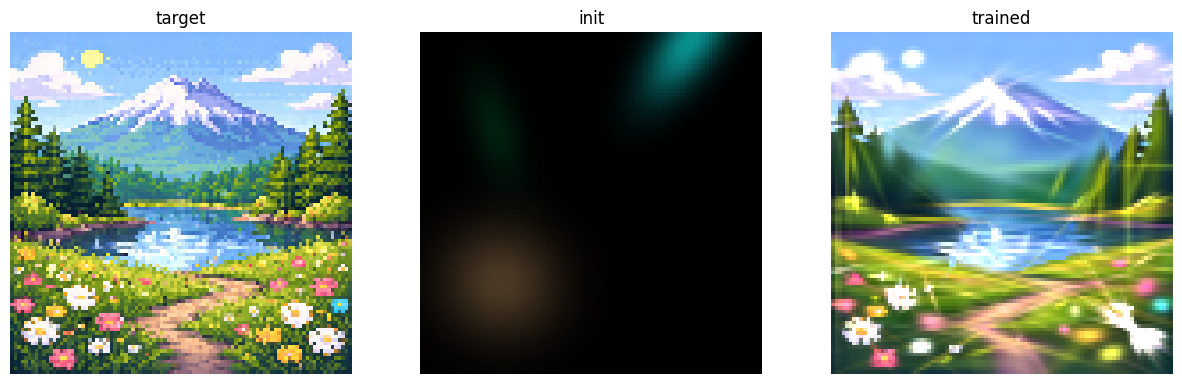

In [23]:
final_fig, final_ax = plt.subplots(1,3, figsize=(15,5))
final_ax[0].axis('off')
final_ax[1].axis('off')
final_ax[2].axis('off')
final_ax[0].set_title('target')
final_ax[1].set_title('init')
final_ax[2].set_title('trained')
final_ax[0].imshow(target_image.detach().cpu().numpy(), extent=[-1, 1, -1, 1], vmin=0.0, vmax=1.0, interpolation="nearest", origin="upper")
final_ax[1].imshow(frames[0].detach().cpu().numpy(), extent=[-1, 1, -1, 1], vmin=0.0, vmax=1.0, interpolation="nearest", origin="upper")
final_ax[2].imshow(frames[-1].detach().cpu().numpy(), extent=[-1, 1, -1, 1], vmin=0.0, vmax=1.0, interpolation="nearest", origin="upper")

final_ax[0].set_xlim(-1, 1)
final_ax[1].set_xlim(-1, 1)
final_ax[2].set_xlim(-1, 1)

plt.show()